## Test ensemble HBV

### ToDo
- automate in .py?
- fix links to forcing and shapefiles etc
- auto delete files

In [1]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

# General eWaterCycle
import ewatercycle
import ewatercycle.forcing
import ewatercycle.models


# progressbar
from tqdm.notebook import tqdm

#fiona
import fiona
import fiona
import shapely.geometry
from pyproj import Geod

#timezone
import pytz

In [2]:
# The name of the shapefile
shape_file_name = "GRDC_Kerki"  # river: Bedford Ouse at Roxton, England

# The time-window of the experiment
experiment_start_date = "1990-01-01T00:00:00Z"
experiment_end_date = "1990-12-31T00:00:00Z"

experiment_end_date = "1960-01-01T00:00:00Z"
datetime_end = pd.to_datetime(experiment_end_date)
datetime_end_naive = datetime_end.tz_localize(None)

forcing_path_ERA5 = (
    Path.home()
    / "MSc_AralSea"
    / "book"
    / "thesis_projects"
    / "MSc"
    / "2025_Q1_AndreVanDerVeen_CEG"
    / "work_in_progress"
    / "forcing"
    / "output"
    / "forcing_HBV_ERA5_GRDC_Kerki_5020"
    / shape_file_name
    / "ERA5"
    / "own_shapefile"
)



load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script" 
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)


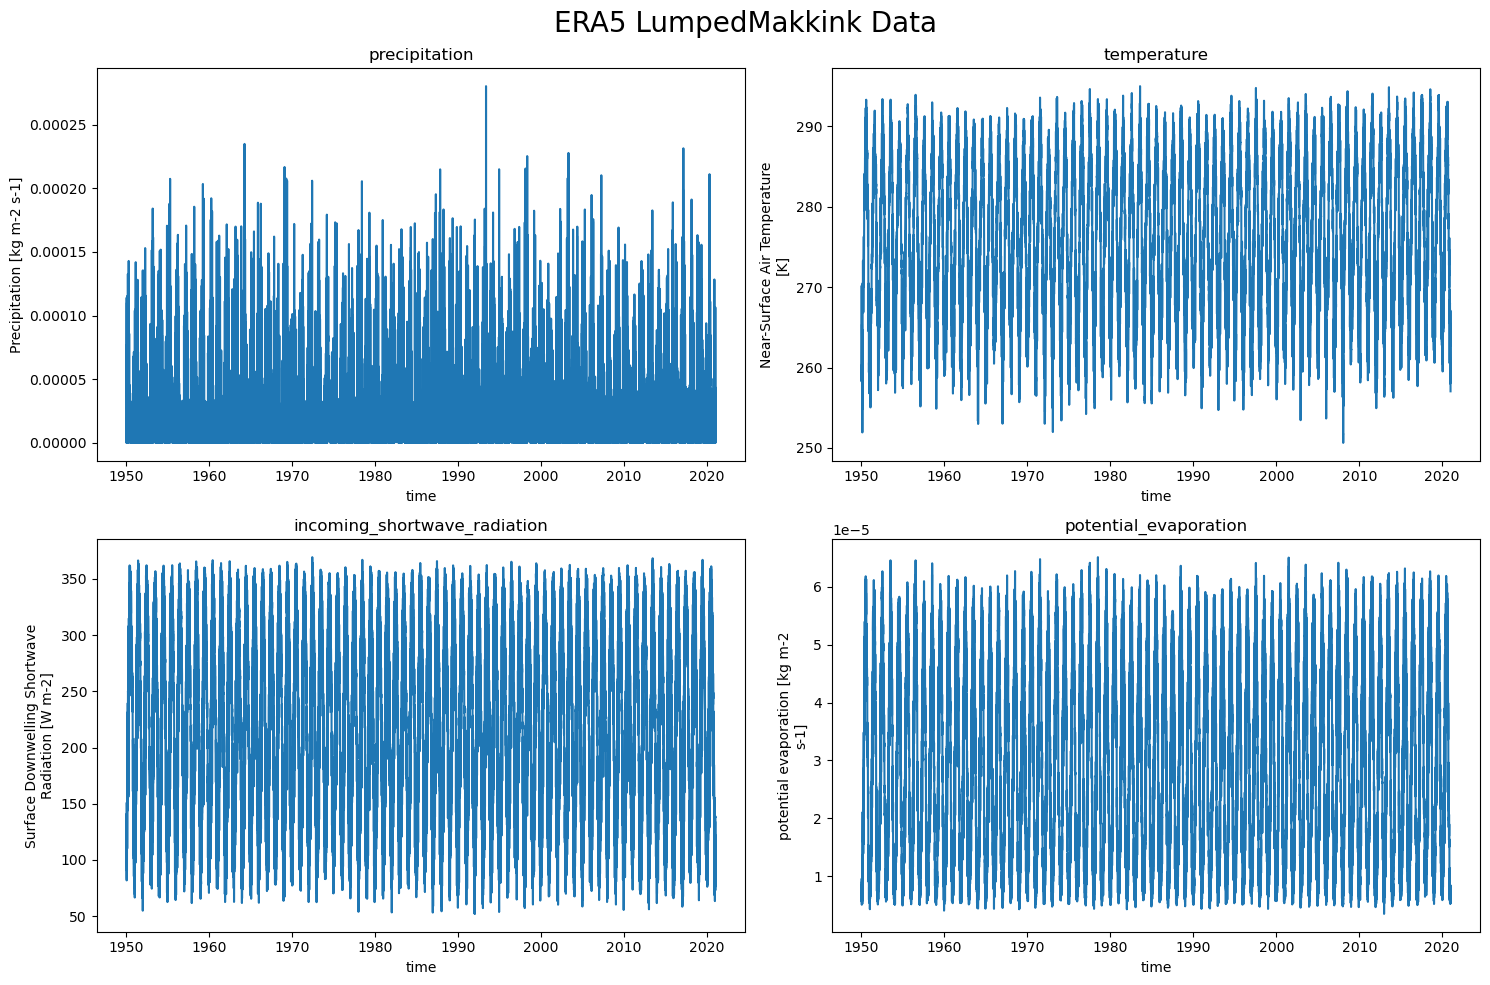

In [3]:
ERA5_data = {'precipitation pr': xr.open_dataset(ERA5_forcing['pr']),
             'temperature tas': xr.open_dataset(ERA5_forcing['tas']),
             'incoming_shortwave_radiation rsds': xr.open_dataset(ERA5_forcing['rsds']),
             'potential_evaporation evspsblpot': xr.open_dataset(ERA5_forcing['evspsblpot'])

             
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in ERA5_data.items():
    plt.subplot(2,2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("ERA5 LumpedMakkink Data", fontsize=20)
plt.tight_layout()

In [4]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(2617110,
                   '1900-01-01T00:00Z',
                   '2000-12-31T00:00Z',
                   data_home='/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/')



In [5]:
n_particles = 250

In [6]:
## Array of initial storage terms - we keep these constant for now
##              Si,  Su, Sf, Ss
s_0 = np.array([0,  100,  0,  5, 0])

## Array of parameters min/max bounds as a reference
##                      Imax,  Ce,  Sumax, beta,  Pmax,  T_lag,   Kf,   Ks,    Fm
parameter_set_fromsomewhere =  [
    7.085,  # Imax
    0.837,  # Ce
    76.373, # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226   # FM
]


param_array = np.array(parameter_set_fromsomewhere)
# p_min_initial = np.array(parameter_set_fromsomewhere) * [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.1, 0.1, 0.5]
# p_max_initial = np.array(parameter_set_fromsomewhere) * [1.5, 2.5, 1.5, 1.5, 1.5, 5, 2, 2, 1.5]
##                      Imax,  Ce,   Sumax,  beta,   Pmax,   T_lag,    Kf,    Ks,     Fm            
#p_min_initial=  0.3 * param_array #np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
#p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
p_max_initial =np.array([25,    1,  800,   4,    .3,     15,    .02,   .01,      0.8])
#p_max_initial =np.array([25,    1,  800,   4,    .3,     80,    .1,   .01,      1])
#p_max_initial = 10 * param_array #np.array(10*parameter_set_fromsomewhere) # np.array([25,    1,  800,   4,    .3,     100,    .1,   .01,      1])
array_random_num = np.array([[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)])
p_initial = p_min_initial + array_random_num * (p_max_initial-p_min_initial)




p_names = ["$I_{max}$",  "$C_e$",  "$Su_{max}$", "β",  "$P_{max}$",  "$T_{lag}$",   "$K_f$",   "$K_s$"]
S_names = ["Interception storage", "Unsaturated Rootzone Storage", "Fastflow storage", "Groundwater storage"]
param_names = ["Imax","Ce",  "Sumax", "Beta",  "Pmax",  "Tlag",   "Kf",   "Ks", "Fm"]
stor_names = ["Si", "Su", "Sf", "Ss", "Sp"]

# set initial as mean of max,min
#par_0 = (p_min_initial + p_max_initial)/2

In [7]:
array_random_num = np.array([[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)])
p_initial = p_min_initial + array_random_num * (p_max_initial-p_min_initial)

In [8]:
all_discharges = []
all_param_values = []


for i in tqdm(range(n_particles), desc="Running HBV experiments"):
    params = dict(zip(param_names, p_initial[i]))
    params_array = p_initial[i]

    model = ewatercycle.models.HBV(forcing=ERA5_forcing)

    cfg_file, _ = model.setup(parameters=params_array, initial_storage=s_0)
    model.initialize(cfg_file)

    Q_m = []
    time = []

    while model.time_as_datetime <datetime_end_naive:
        model.update()
        Q_m.append(model.get_value("Q")[0])                # punt-HBV, 1-element array
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Q per timestep
    discharge_da = xr.DataArray(Q_m, coords={"time": time}, dims=["time"])
    discharge_da = discharge_da.expand_dims("particle").assign_coords(particle=[i])
    all_discharges.append(discharge_da)

    # parameters as DataArray
    param_da = xr.DataArray(p_initial[i], coords={"parameter": param_names}, dims=["parameter"])
    param_da = param_da.expand_dims("particle").assign_coords(particle=[i])
    all_param_values.append(param_da)

# combine data arrays
discharge_ensemble = xr.concat(all_discharges, dim="particle")
param_array = xr.concat(all_param_values, dim="particle")




Running HBV experiments:   0%|          | 0/250 [00:00<?, ?it/s]

In [9]:
    discharge_da 

<xarray.DataArray (particle: 1, time: 3652)> Size: 29kB
array([[0.00014175, 0.00057717, 0.00132634, ..., 0.13133792, 0.13001187,
        0.12870229]])
Coordinates:
  * time      (time) datetime64[ns] 29kB 1950-01-02T12:00:00 ... 1960-01-01T1...
  * particle  (particle) int64 8B 249

In [10]:
discharge_ensemble

<xarray.DataArray (particle: 250, time: 3652)> Size: 7MB
array([[1.67441821e-04, 6.71170687e-04, 1.51398564e-03, ...,
        7.05405568e-02, 7.03542924e-02, 7.01697688e-02],
       [1.79906144e-03, 7.25928653e-03, 1.65039214e-02, ...,
        2.80943201e-02, 2.78040261e-02, 2.75171488e-02],
       [6.71162188e-04, 2.68281644e-03, 6.03130712e-03, ...,
        1.37166331e-01, 1.35672694e-01, 1.34201792e-01],
       ...,
       [1.25125168e-03, 4.99762652e-03, 1.12244083e-02, ...,
        4.49981375e-02, 4.43319548e-02, 4.36757223e-02],
       [4.80321552e-04, 1.93850189e-03, 4.40863616e-03, ...,
        1.81600307e-01, 1.79470246e-01, 1.77367583e-01],
       [1.41752240e-04, 5.77170707e-04, 1.32633851e-03, ...,
        1.31337918e-01, 1.30011870e-01, 1.28702286e-01]])
Coordinates:
  * time      (time) datetime64[ns] 29kB 1950-01-02T12:00:00 ... 1960-01-01T1...
  * particle  (particle) int64 2kB 0 1 2 3 4 5 6 ... 243 244 245 246 247 248 249

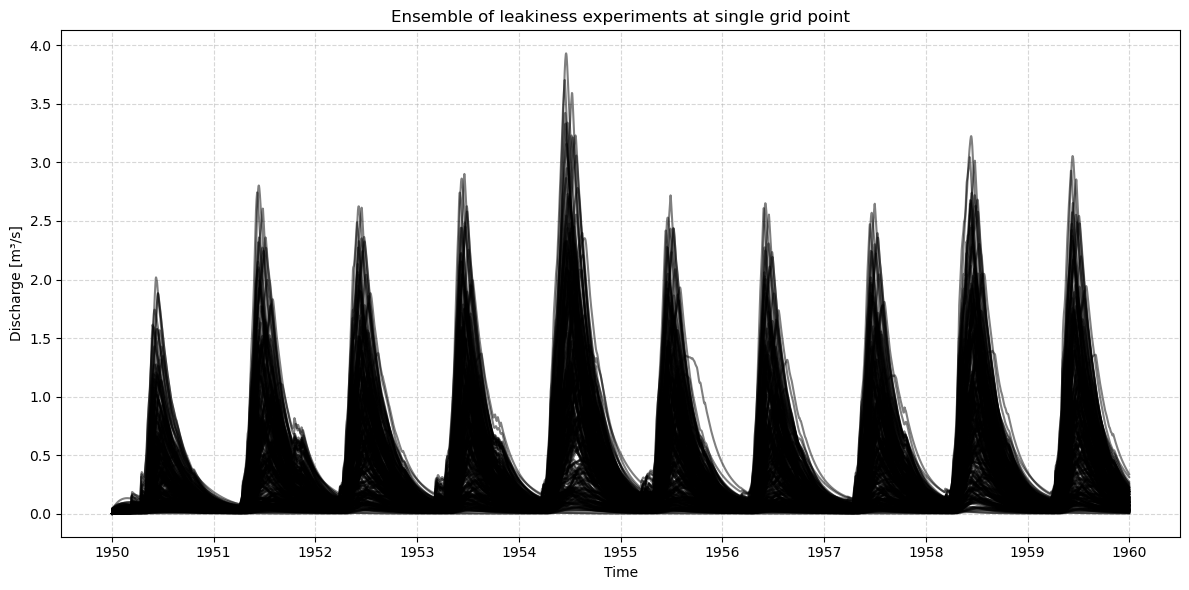

In [11]:


discharge_1955 = discharge_ensemble.sel(
    time=slice("1950-01-01", "1959-12-31")
)


plt.figure(figsize=(12,6))

for i, leak in enumerate(discharge_1955.particle.values):
    plt.plot(
        discharge_1955.time,
        discharge_1955.isel(particle=i),
        label=f"leakiness={leak:.2f}",
        color = 'black',
        alpha = 0.5
    )

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of leakiness experiments at single grid point")
#plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [12]:
def catchment_area_from_shapefile(shapefile_path, ellps="WGS84"):
    """
    Compute the area (in m²) of the first polygon in a shapefile.

    Parameters
    ----------
    shapefile_path : str
        Path to the shapefile (.shp)
    ellps : str, optional
        Ellipsoid for area calculation (default: WGS84)

    Returns
    -------
    float
        Absolute area of the polygon in square meters
    """
    # Load polygon
    with fiona.open(shapefile_path) as src:
        poly = shapely.geometry.shape(src[0]["geometry"])

    # Define ellipsoid
    geod = Geod(ellps=ellps)

    # Compute area and perimeter
    area, _ = geod.geometry_area_perimeter(poly)

    return abs(area)

In [13]:
area_Kerki = catchment_area_from_shapefile(
    "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/AralSea_Basin/GRDC_Kerki/GRDC_Kerki.shp"
)
conversion_mmday2m3s = 1 / (1000 * 86400)

conversion_factor = conversion_mmday2m3s * area_Kerki

In [14]:
discharge_m3s = discharge_ensemble * conversion_factor

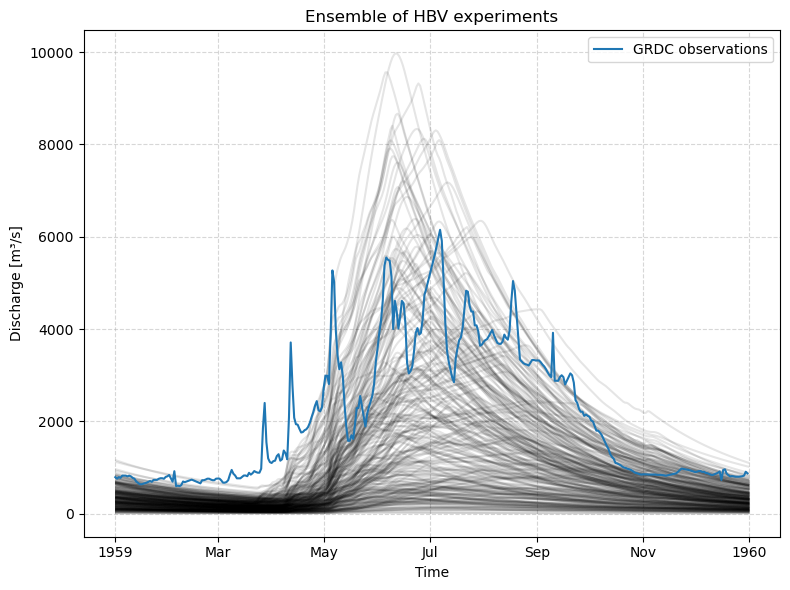

In [15]:


discharge_1955_m3 = discharge_m3s.sel(
    time=slice("1959-01-01", "1959-12-31")
)
ds_slice = ds.sel(time=slice("1959-01-01", "1959-12-31"))


plt.figure(figsize=(8,6))

for i, leak in enumerate(discharge_1955_m3.particle.values):
    plt.plot(
        discharge_1955_m3.time,
        discharge_1955_m3.isel(particle=i),
        #label=f"particle {leak}",
        color = 'black',
        alpha = 0.1
    )


ds_slice['streamflow'].plot(label = 'GRDC observations')

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of HBV experiments")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
#plt.ylim(0,max_y)
plt.show()

In [17]:
discharge_ensemble.name = "discharge"
discharge_ensemble.attrs["units"] = "mm/day"
discharge_ensemble.to_netcdf("HBV_Kerki_ensemble_5059_mmd.nc")

discharge_m3s.name = "discharge"
discharge_m3s.attrs["units"] = "m3/s"
discharge_m3s.to_netcdf("HBV_Kerki_ensemble_5059_m3s.nc")

param_array.name = "hbv_parameters"
param_array.attrs["description"] = "HBV parameter values per ensemble member"
param_array.to_netcdf("HBV_Kerki_ensemble_5059_params.nc")


In [18]:
discharge_ensemble

<xarray.DataArray 'discharge' (particle: 250, time: 3652)> Size: 7MB
array([[1.67441821e-04, 6.71170687e-04, 1.51398564e-03, ...,
        7.05405568e-02, 7.03542924e-02, 7.01697688e-02],
       [1.79906144e-03, 7.25928653e-03, 1.65039214e-02, ...,
        2.80943201e-02, 2.78040261e-02, 2.75171488e-02],
       [6.71162188e-04, 2.68281644e-03, 6.03130712e-03, ...,
        1.37166331e-01, 1.35672694e-01, 1.34201792e-01],
       ...,
       [1.25125168e-03, 4.99762652e-03, 1.12244083e-02, ...,
        4.49981375e-02, 4.43319548e-02, 4.36757223e-02],
       [4.80321552e-04, 1.93850189e-03, 4.40863616e-03, ...,
        1.81600307e-01, 1.79470246e-01, 1.77367583e-01],
       [1.41752240e-04, 5.77170707e-04, 1.32633851e-03, ...,
        1.31337918e-01, 1.30011870e-01, 1.28702286e-01]])
Coordinates:
  * time      (time) datetime64[ns] 29kB 1950-01-02T12:00:00 ... 1960-01-01T1...
  * particle  (particle) int64 2kB 0 1 2 3 4 5 6 ... 243 244 245 246 247 248 249
Attributes:
    units:    mm/day

In [19]:
# max per particle
max_per_particle = discharge_1955_m3.max(dim="time")  # DataArray met dim particle

# particle with highest max value
particle_idx = max_per_particle.argmax().item()  #returns index

# highest value
highest_discharge = max_per_particle.max().item()

print(f"Particle {particle_idx} has the highest max discharge: {highest_discharge}")

Particle 90 has the highest max discharge: 9970.902288582598

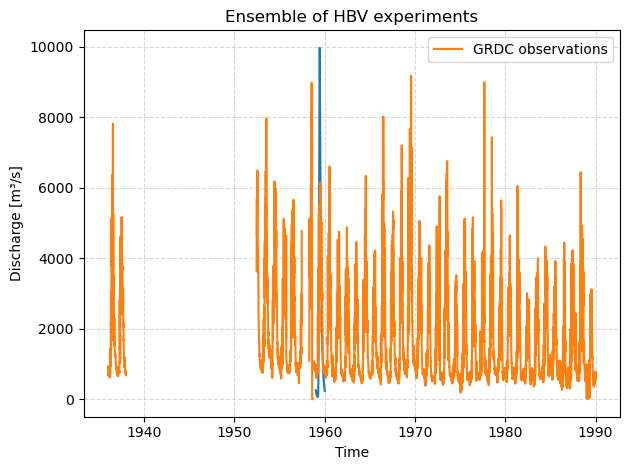

In [20]:
plt.plot(
    discharge_1955_m3.time,
    discharge_1955_m3.isel(particle=particle_idx),

    )


#plot GRDC
max_y = 2*ds['streamflow'].max()
ds['streamflow'].plot(label = 'GRDC observations')

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of HBV experiments")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
#plt.ylim(0,max_y)
plt.show()

In [21]:
import pandas as pd
import hydrostats as hs
import hydrostats.analyze as ha
from hydrostats.metrics import me, r_squared, rmse, kge_2012, nse, dr, nse_mod, nse_rel, kge_2009


df = pd.DataFrame({
    "obs": ds["streamflow"].values[:1095],
    "sim": discharge_1955_m3.isel(particle=particle_idx).values[:1095]
}, index=ds["streamflow"].time[:1095])  

# merge_data kan dan gebruikt worden met DataFrames
merged_df = hs.data.merge_data(sim_df=df["sim"], obs_df=df["obs"], column_names=("sim","obs"))

ValueError: Length of values (365) does not match length of index (1095)

In [ ]:
merged_df

In [22]:
# maak de time-lag plot
_ = ha.time_lag(
    merged_df,
    shift_range=(-90, 90),
    metrics=[nse.abbr, kge_2012.abbr, dr.abbr, kge_2009.abbr, nse_rel.abbr, nse_mod.abbr],
    plot=True
)


NameError: name 'merged_df' is not defined

In [23]:
time_lag_df, summary_df = ha.time_lag(merged_df,shift_range=(-90, 90), metrics=[nse.abbr, nse_rel.abbr, nse_mod.abbr,kge_2009.abbr, kge_2012.abbr, dr.abbr])

NameError: name 'merged_df' is not defined

In [24]:
time_lag_df.plot()
plt.grid(linestyle = '--', alpha =0.5)
plt.title("Metric values between as different time lags")
plt.ylabel("Metric Value [-]")
plt.xlabel("Time lag [days]")

NameError: name 'time_lag_df' is not defined